## EEG data in the dying human brain  : artifact detection





DATASET : 

- Original paper :  Surge of neurophysiological coupling and connectivity of gamma oscillations in the dying human brain (Xu et al.,2023) https://www.pnas.org/doi/abs/10.1073/pnas.2216268120

- Data available here : https://zenodo.org/records/7803212#.ZC3Cb-zML0q

- Supporting information available here : https://universityofsussex-my.sharepoint.com/:b:/r/personal/rb666_sussex_ac_uk/Documents/Projects/LZ%20NDE/Supplementary%20pnas.2216268120.sapp.pdf?csf=1&web=1&e=TY5ZjD


Materials and Methods
Data Preprocessing.
The original sampling frequency from the data recordings was 512 Hz. The 19 EEG channels from the international 10/20 system recorded with the Fpz reference were rereferenced by subtracting the average potential from each channel at each time point. A notch filter was used to remove the 60-Hz artifact and its superharmonics in EEG signals. The 6 frequency bands were defined as delta (0 to 4 Hz), theta (4 to 8 Hz), alpha (8 to 13 Hz), beta (13 to 25 Hz), gamma1 (25 to 55 Hz), and gamma2 (80 to 150 Hz).

---------------------------------------------------------------------

@Code : Romy Beauté\
@Contact : r.beaut@sussex.ac.uk\
@Date : 22/02/24\
@Last modified : 22/02/24

In [14]:
%matplotlib widget
# %matplotlib inline
# %matplotlib notebook


import matplotlib
import matplotlib.pyplot as plt
import mne
from mne.preprocessing import ICA
import numpy as np
import os
import sys
from helper4pipeline import read_pipeline_EEG,new_names

###################### Hand made libraries ######################
# Append the path of the EEGInterface_META library to use its modules
sys.path.append('/Users/rb666/projects/EEGInterface_META')
sys.path.append('/Users/rb666/projects/LZcNDE_META')

# For visualisation
from visualisation import read_EEG
from manual_preprocessing import *
from helper import *

# Clinical infomations
from stages_infos import *

#For computing LZc
from univariate_LZc import *



In [15]:
# #####################  SELECT DATASET ####################################################################
DATASET_name = "Gang_2023"
patient = 1
stage = 1#"2-end" #can be 1 or "2-end"

############################################################################################################

DATASET_path = os.path.expanduser(f"~/projects/DATA/EEG/{DATASET_name}")
preprocessed_folder = os.path.join(DATASET_path, "preprocessed")
save_preproc = True

EEG_files = os.listdir(DATASET_path)
print(f"EEG files in {DATASET_name} : {[file for file in EEG_files if file.endswith('.edf')]}")


EEG files in Gang_2023 : ['Pt2_S1.edf', 'Pt1_S2-end.edf', 'Pt4_S2-end.edf', 'Pt4_S1.edf', 'Pt3_S2-end.edf', 'Pt3_S1.edf', 'Pt1_S1.edf', 'Pt2_S2-end.edf']


STAGE 1

In [16]:

EEG_file = 'Pt{}_S{}.edf'.format(patient, stage)
EEG_file_path = os.path.join(DATASET_path, EEG_file)
print(f"Loading {EEG_file_path}")

raw = read_pipeline_EEG(EEG_file,DATASET_path)
length_rec = raw.times[-1] + 1/raw.info['sfreq']
print(f"Length recording : {length_rec} s")
print(f"N samples : {raw.n_times}")
print("---------------------------------------")
print(f"Details for file: {EEG_file}")
print(raw.info)
print("---------------------------------------")



#check if annotated events
raw.info.keys()
raw.info['events']
print(raw.annotations)
events, event_ids = mne.events_from_annotations(raw)
print(events,event_ids)

#check if projection in the data
if not raw.info["projs"]:
    print("No projection in the data")
else: 
    print(raw.info["projs"])


Loading /Users/rb666/projects/DATA/EEG/Gang_2023/Pt1_S1.edf
EEG file : Pt1_S1.edf
Extracting EDF parameters from /Users/rb666/projects/DATA/EEG/Gang_2023/Pt1_S1.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 61439  =      0.000 ...   119.998 secs...
Length recording : 120.0 s
N samples : 61440
---------------------------------------
Details for file: Pt1_S1.edf
<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, F7, T3, T5, O1, F3, C3, P3, Fz, Cz, Fp2, F8, T4, T6, O2, ...
 chs: 20 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 256.0 Hz
 meas_date: 2014-06-06 22:02:00 UTC
 nchan: 20
 projs: []
 sfreq: 512.0 Hz
 subject_info: 1 item (dict)
>
---------------------------------------
<Annotations | 0 segments>
[] {}
No projection in the data


### Channels & montage monotoring


Informations on Data Preprocessing from Gang et al.,2023 : The original sampling frequency from the data recordings was 512 Hz. The 19 EEG channels from the international 10/20 system recorded with  the  Fpz  reference  were  rereferenced  by  subtracting  the  average  potential from  each  channel  at  each  time  point.  A  notch  filter  was  used  to  remove  the  60-Hz artifact and its superharmonics in EEG signals. The 6 frequency bands were defined as delta (0 to 4 Hz), theta (4 to 8 Hz), alpha (8 to 13 Hz), beta (13 to 25 Hz), gamma1 (25 to 55 Hz), and gamma2 (80 to 150 Hz).

['Fp1', 'F7', 'T3', 'T5', 'O1', 'F3', 'C3', 'P3', 'Fz', 'Cz', 'Fp2', 'F8', 'T4', 'T6', 'O2', 'F4', 'C4', 'P4', 'Pz', 'EKG1']
['Fp1', 'F7', 'T3', 'T5', 'O1', 'F3', 'C3', 'P3', 'Fz', 'Cz', 'Fp2', 'F8', 'T4', 'T6', 'O2', 'F4', 'C4', 'P4', 'Pz']
No montage associated yet. Proceeding with renaming and setting new montage.


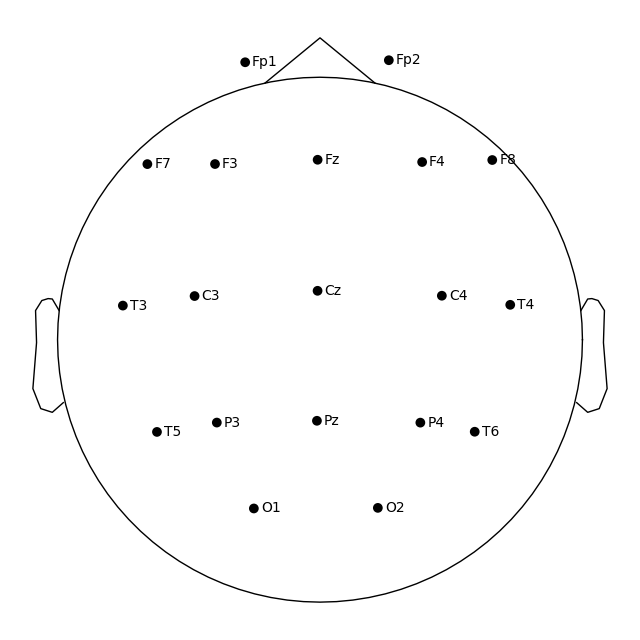

EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
Average reference projection applied.


In [17]:
##### CHANNELS #####

print(raw.info['ch_names'])




# select only EEG channels
eeg_chans = [ch for ch in raw.info['ch_names'] if ch != 'EKG1']


raw_EEG = raw.copy().pick(eeg_chans)

# sanity check to check if EEG and ECG channels well applied to the 2 TS
print(raw_EEG.info['ch_names']) 



##### MONTAGE #####
# Check if existing montage specified 
if raw.info['dig'] is not None and len(raw.info['dig']) > 0:
    print("A montage is already associated with this data.")
else:
    print("No montage associated yet. Proceeding with renaming and setting new montage.")


# apply standard 10-20 montage
montage = mne.channels.make_standard_montage('standard_1020')
raw_EEG = raw_EEG.set_montage(montage)
raw_EEG.plot_sensors(kind='topomap', show_names=True) #check if montage well applied



# Re-reference the EEG data to the average and apply it 
raw_EEG.set_eeg_reference('average', projection=True)
raw_EEG.apply_proj()
print("Average reference projection applied.")


### ECG artefacts detection

['EKG1']
Using channel EKG1 to identify heart beats.
Setting up band-pass filter from 5 - 35 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 5.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 4.75 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 35.25 Hz)
- Filter length: 5120 samples (10.000 s)

Number of ECG events detected : 165 (average pulse 82 / min.)
Not setting metadata
165 matching events found
Setting baseline interval to [-0.19921875, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 165 events and 359 original time points ...
1 bad epochs dropped
Not setting metadata
164 matching events found
No baseline correction applied
0 projection items activated
combining channels using "

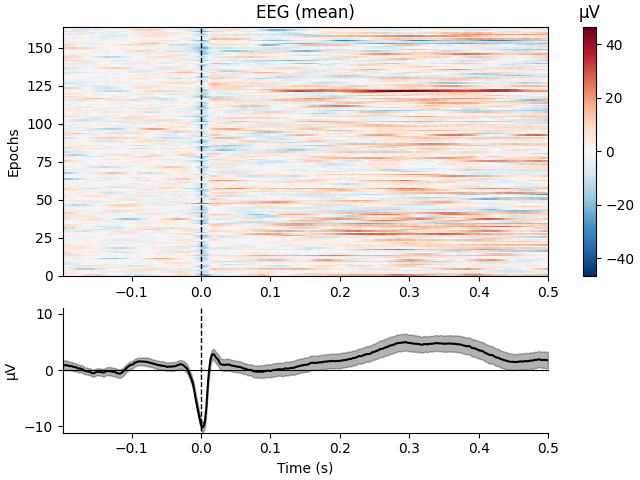

[<Figure size 640x480 with 3 Axes>]

In [18]:
raw_ECG = raw.copy().pick('EKG1')
print(raw_ECG.info['ch_names'])
ecg_events, _, average_pulse, ecg_data = mne.preprocessing.find_ecg_events(raw, ch_name='EKG1', verbose=True, return_ecg=True)

ecg_epochs = mne.Epochs(raw, events=ecg_events,event_id=None, preload=True)
ecg_epochs.plot_image(combine='mean')

# raw_ECG.plot(scalings='auto', title='ECG')

### Power line noise

Effective window size : 4.000 (s)


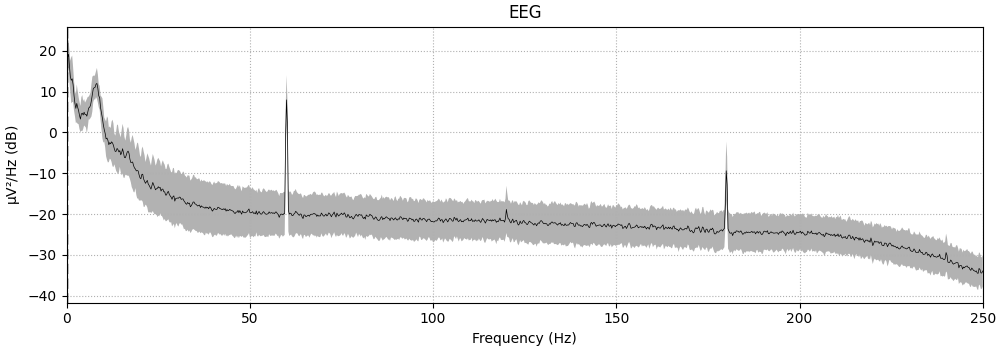

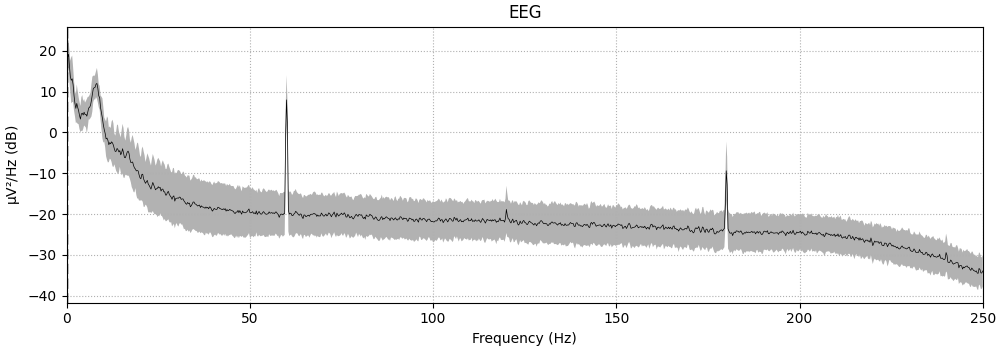

In [19]:
fig = raw.compute_psd(tmax=np.inf, fmax=250).plot(
    average=True, picks="data", exclude="bads"
)
for ax in fig.axes[1:]:
    freqs = ax.lines[-1].get_xdata()
    psds = ax.lines[-1].get_ydata()
    for freq in (60, 120, 180, 240):
        idx = np.searchsorted(freqs, freq)
        ax.arrow(
            x=freqs[idx],
            y=psds[idx] + 18,
            dx=0,
            dy=-12,
            color="red",
            width=0.1,
            head_width=3,
            length_includes_head=True,
        )

### Preprocessing starts 

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 3381 samples (6.604 s)

Fitting ICA to data using 19 channels (please be patient, this may take a while)
    Applying projection operator with 1 vector (pre-whitener computation)
    Applying projection operator with 1 vector (pre-whitener application)
Selecting by explained variance: 13 components


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
/var/folders/1d/q_0fy53s0jdcsc1sb09wkntw00z7v7/T/ipykernel_49944/2089260751.py:9: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw_filtered)


    Applying projection operator with 1 vector (pre-whitener application)
Fitting ICA took 23.6s.
Applying ICA to Raw instance
    Applying projection operator with 1 vector (pre-whitener application)
    Transforming to ICA space (13 components)
    Zeroing out 0 ICA components
    Projecting back using 19 PCA components


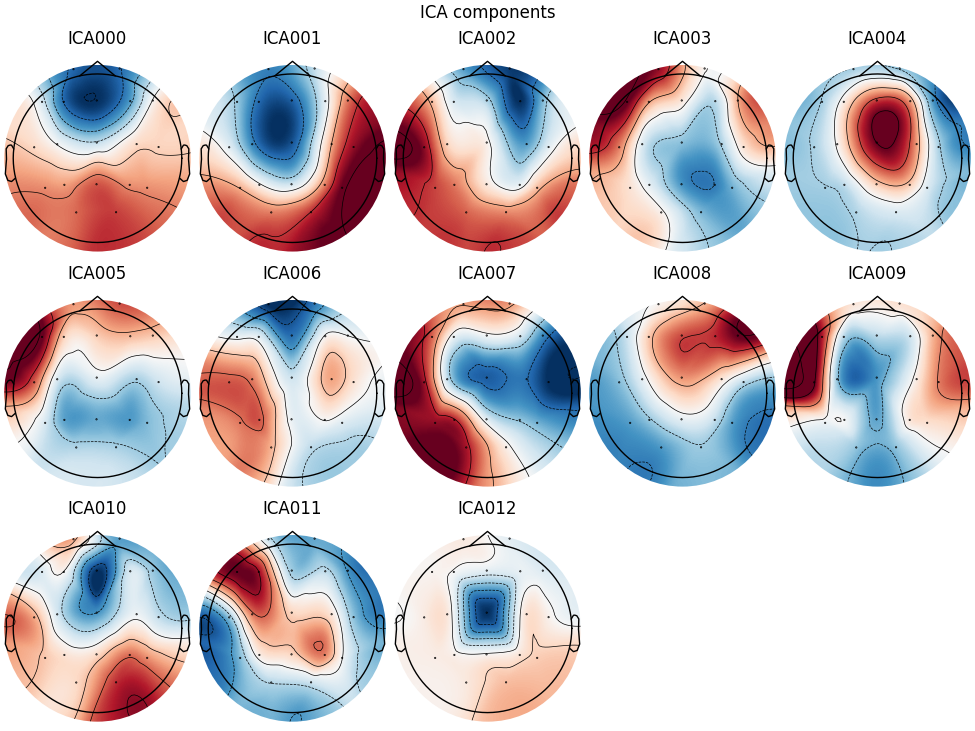

    Applying projection operator with 1 vector (pre-whitener application)
Creating RawArray with float64 data, n_channels=13, n_times=30000
    Range : 0 ... 29999 =      0.000 ...   119.996 secs
Ready.


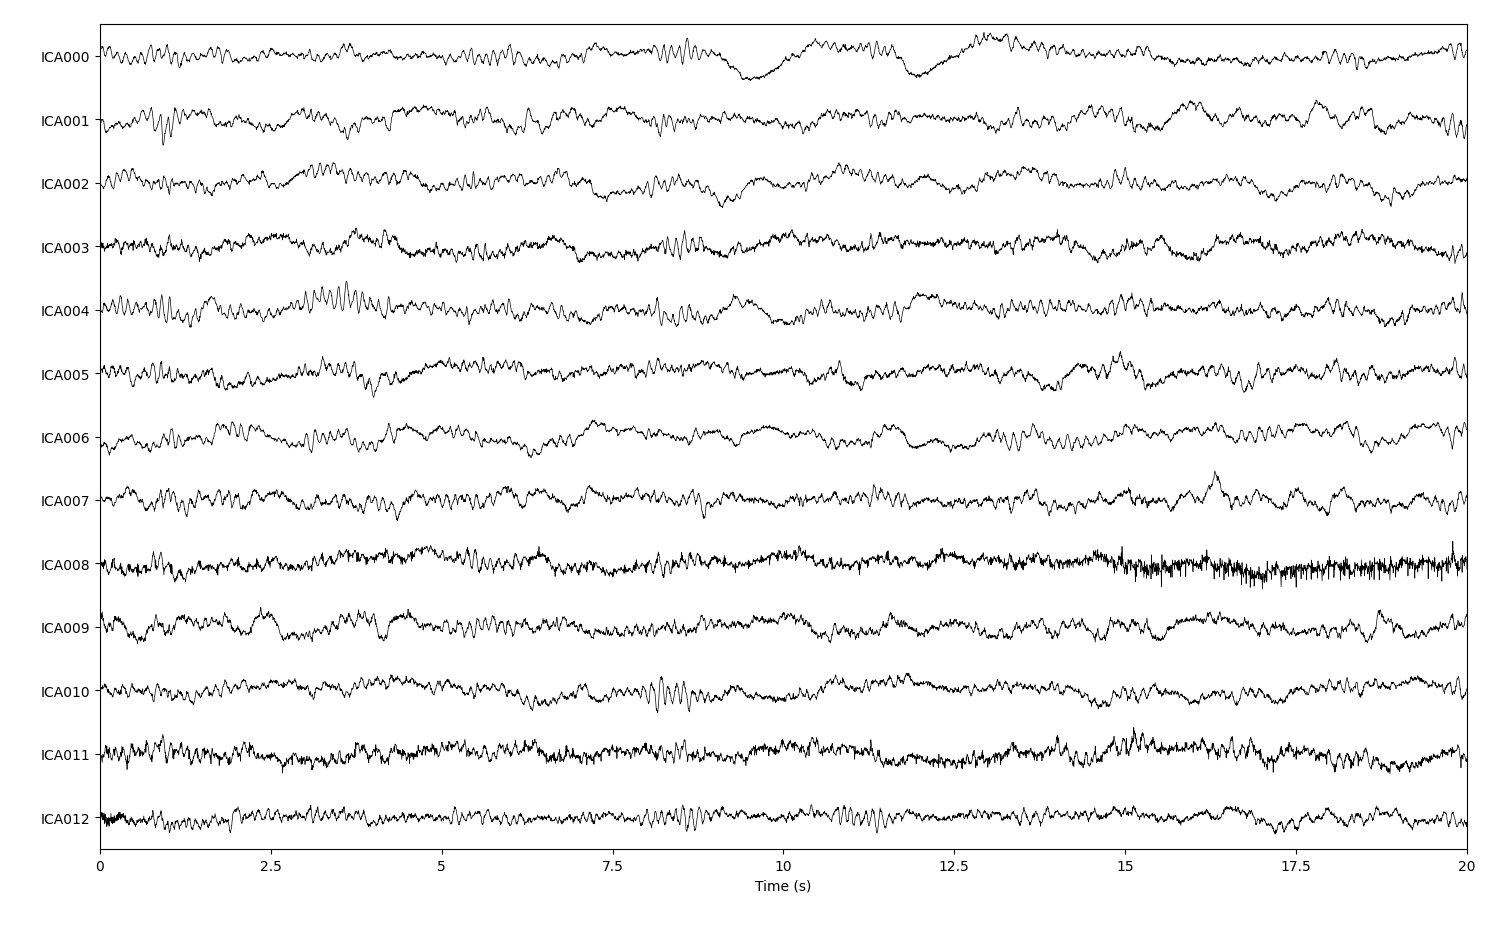

Setting channel interpolation method to {'eeg': 'spline'}.
Fraction of eeg variance explained by all components: 0.9905035100475796
Fraction of variance in EEG signal explained by first component: 28%


/var/folders/1d/q_0fy53s0jdcsc1sb09wkntw00z7v7/T/ipykernel_49944/2089260751.py:15: RuntimeWarning: No bad channels to interpolate. Doing nothing...
  raw_filtered.interpolate_bads(reset_bads=True)


In [20]:
#apply 60Hz notch filter and downsample to 250Hz
apply_ica = True
raw_filtered = raw_EEG.copy().notch_filter(freqs=60) #nothc filter
raw_filtered = raw_filtered.resample(sfreq=250) #downsample to 250Hz
# raw_filtered.plot()

if apply_ica :
    ica = mne.preprocessing.ICA(n_components=0.99, random_state=77, max_iter="auto", method="picard")
    ica.fit(raw_filtered)
    ica.apply(raw_filtered)
    ica.plot_components()
    ica.plot_sources(raw_filtered, show_scrollbars=False)


raw_filtered.interpolate_bads(reset_bads=True)



explained_var_ratio = ica.get_explained_variance_ratio(raw_filtered)
for channel_type, ratio in explained_var_ratio.items():
    print(
        f"Fraction of {channel_type} variance explained by all components: " f"{ratio}"
    )

explained_var_ratio = ica.get_explained_variance_ratio(
    raw_filtered, components=[0], ch_type="eeg"
)
# print as percentage.
ratio_percent = round(100 * explained_var_ratio["eeg"])
print(
    f"Fraction of variance in EEG signal explained by first component: "
    f"{ratio_percent}%"
)

### Compare ICA after having removed first slow drifts*

*from MNE python : "Before we run the ICA, an important step is filtering the data to remove low-frequency drifts, which can negatively affect the quality of the ICA fit. The slow drifts are problematic because they reduce the independence of the assumed-to-be-independent sources (e.g., during a slow upward drift, the neural, heartbeat, blink, and other muscular sources will all tend to have higher values), making it harder for the algorithm to find an accurate solution. A high-pass filter with 1 Hz cutoff frequency is recommended."

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 1691 samples (3.303 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 3381 sample

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Selecting by explained variance: 13 components
    Applying projection operator with 1 vector (pre-whitener application)
Fitting ICA took 8.7s.
Applying ICA to Raw instance
    Applying projection operator with 1 vector (pre-whitener application)
    Transforming to ICA space (13 components)
    Zeroing out 0 ICA components
    Projecting back using 19 PCA components


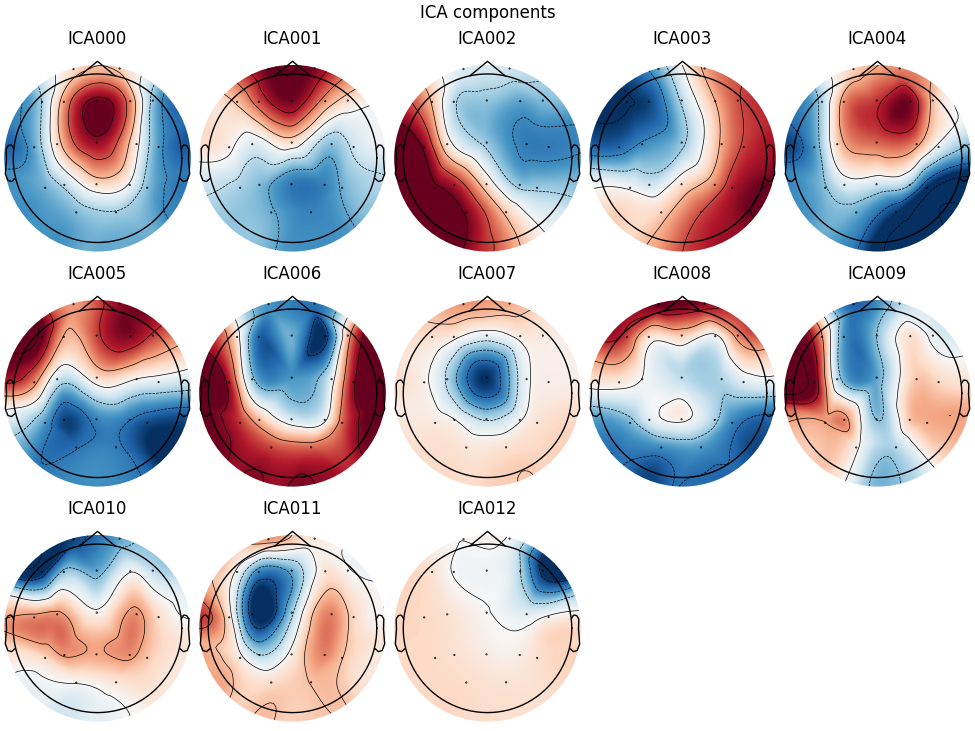

    Applying projection operator with 1 vector (pre-whitener application)
Creating RawArray with float64 data, n_channels=13, n_times=30000
    Range : 0 ... 29999 =      0.000 ...   119.996 secs
Ready.


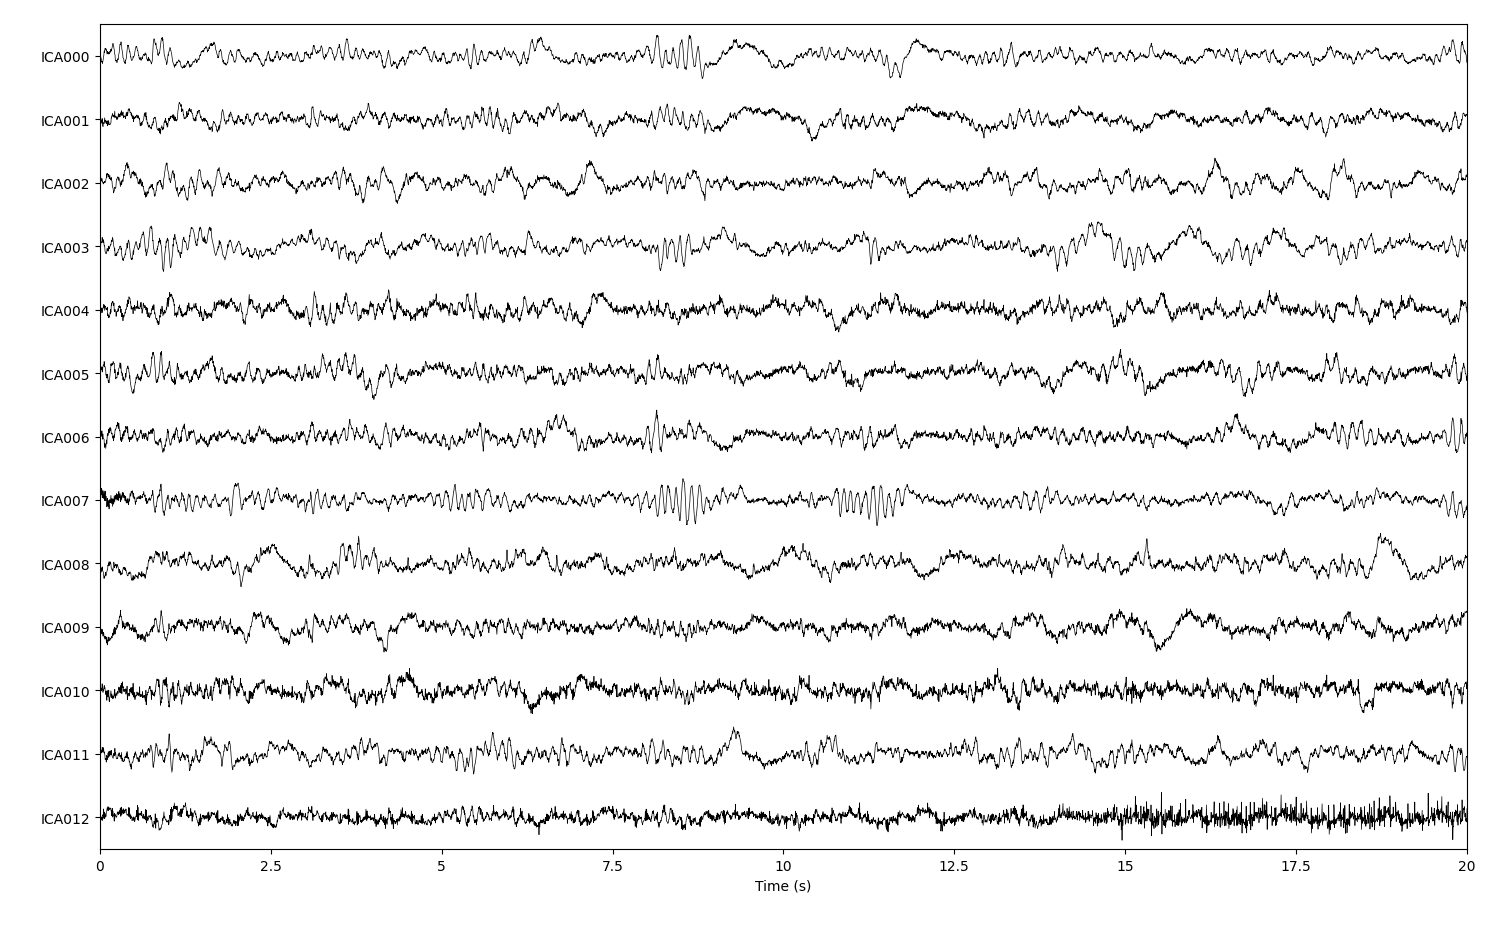

Setting channel interpolation method to {'eeg': 'spline'}.
Fraction of eeg variance explained by all components: 0.9925906202090375
Fraction of variance in EEG signal explained by first component: 19%


/var/folders/1d/q_0fy53s0jdcsc1sb09wkntw00z7v7/T/ipykernel_49944/1977311389.py:15: RuntimeWarning: No bad channels to interpolate. Doing nothing...
  raw_filtered_ld.interpolate_bads(reset_bads=True)


In [21]:
#apply 60Hz notch filter and downsample to 250Hz
apply_ica = True
raw_filtered_ld = raw_EEG.copy().filter(l_freq=1.0,h_freq=None)
raw_filtered_ld = raw_filtered_ld.notch_filter(freqs=60) #nothc filter
raw_filtered_ld = raw_filtered_ld.resample(sfreq=250) #downsample to 250Hz
# raw_filtered_ld.plot()

if apply_ica :
    ica = mne.preprocessing.ICA(n_components=0.99, random_state=77, max_iter="auto",method="picard")
    ica.fit(raw_filtered_ld)
    ica.apply(raw_filtered_ld)
    ica.plot_components()
    ica.plot_sources(raw_filtered_ld, show_scrollbars=False)

raw_filtered_ld.interpolate_bads(reset_bads=True)


explained_var_ratio = ica.get_explained_variance_ratio(raw_filtered_ld)
for channel_type, ratio in explained_var_ratio.items():
    print(
        f"Fraction of {channel_type} variance explained by all components: " f"{ratio}"
    )

explained_var_ratio = ica.get_explained_variance_ratio(
    raw_filtered_ld, components=[0], ch_type="eeg"
)
# print as percentage.
ratio_percent = round(100 * explained_var_ratio["eeg"])
print(
    f"Fraction of variance in EEG signal explained by first component: "
    f"{ratio_percent}%"
)


    Applying projection operator with 1 vector (pre-whitener application)
    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
60 matching events found
No baseline correction applied
0 projection items activated


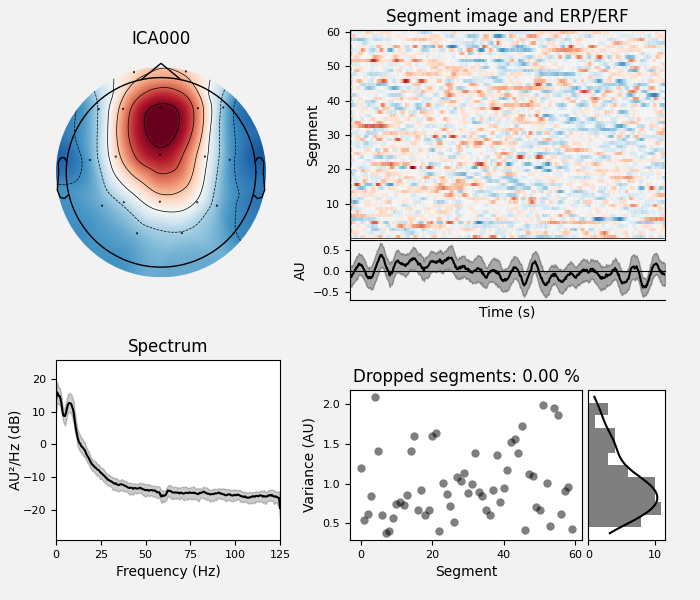

[<Figure size 700x600 with 6 Axes>]

In [22]:
ica.plot_properties(raw_filtered_ld, picks=0)

### Events and epochs definition 

Verifying if events

In [23]:
baseline_correction = False
epoch_duration = 2.0
detrend = True
normalise = True
save_preproc = True


if event_ids:
    # convert annotations to events
    events, event_id = mne.events_from_annotations(raw)
    print("Events from annotations:", events)
    
    if not baseline_correction:
        # Create epochs without baseline correction
        epochs = mne.Epochs(raw_filtered, events, event_id=event_id, tmin=0, tmax=epoch_duration, preload=True, baseline=None) #no baseline correction
        print("Created 2-second epochs without baseline correction:", epochs)

    else:
        # Create epochs with baseline correction, assuming a suitable baseline period exists
        epochs = mne.Epochs(raw_filtered, events, event_id=event_id, tmin=0, tmax=epoch_duration, preload=True, baseline=(-0.2, 0))
        print("Created 2-second epochs with baseline correction:", epochs)



    # downsample the epochs data to 250Hz
    epochs_resampled = epochs.resample(250, npad='auto')
    print("Downsampled to 250Hz")

else:
    print('No events found in the annotations. Working on the whole dataset')
    

No events found in the annotations. Working on the whole dataset


To defining epochs manally without annotated events

Not setting metadata
60 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 60 events and 501 original time points ...
1 bad epochs dropped


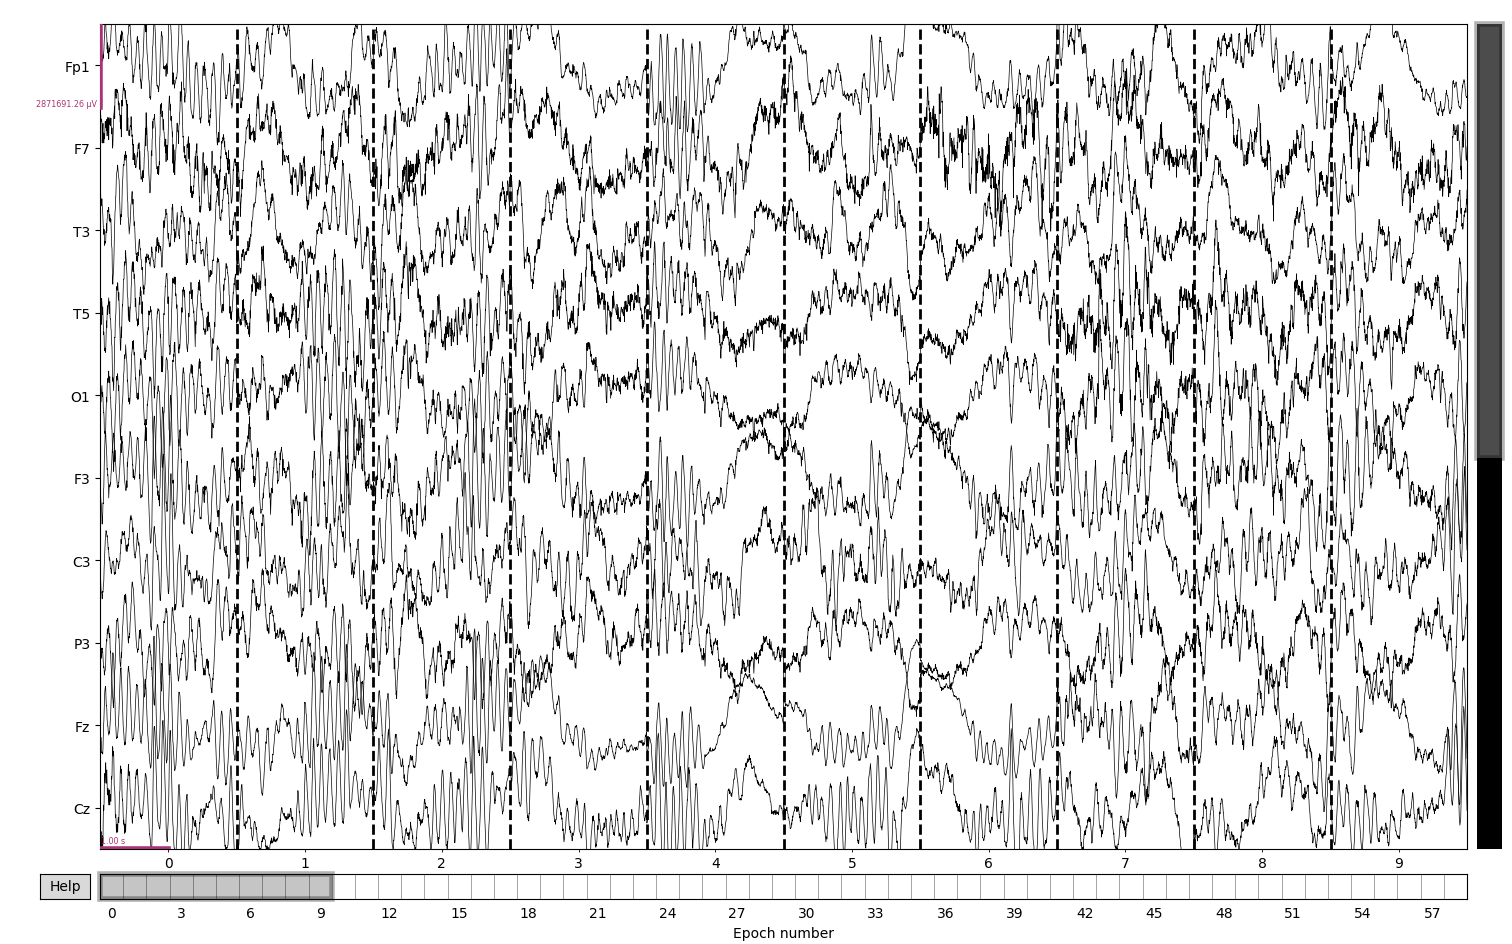

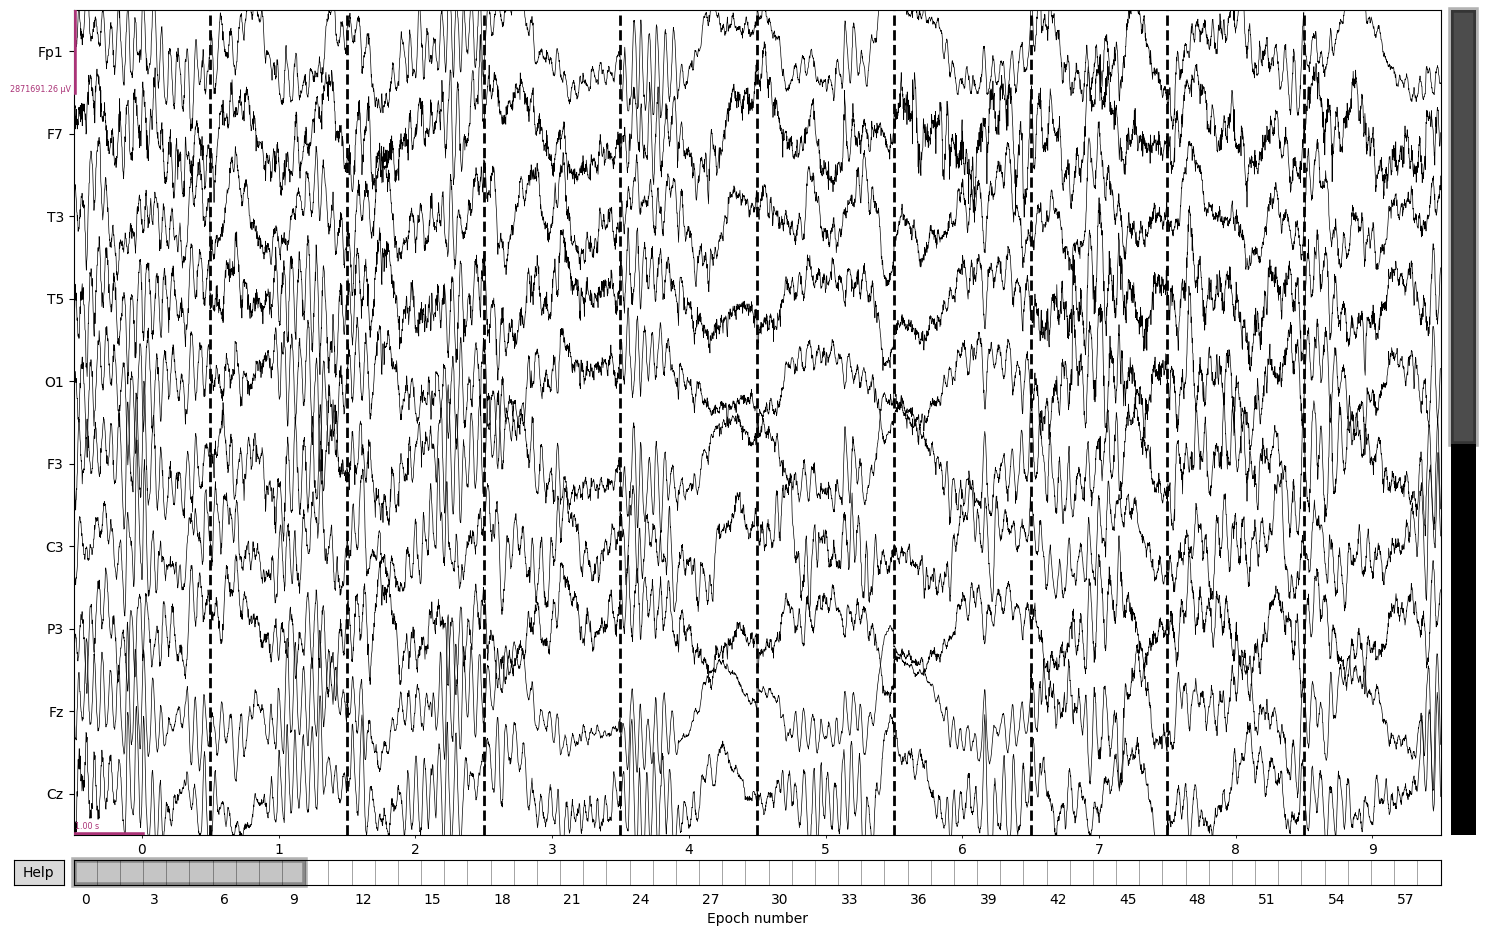

In [24]:
# Epoching
picks = mne.pick_types(raw_filtered.info, meg=False, eeg=True,exclude=['EKG1']) #select only EEG channels
events = mne.make_fixed_length_events(raw_filtered, duration=epoch_duration) #create events that are spaced by the duration of each epoch
epochs = mne.Epochs(raw_filtered, events, tmin=0, tmax=epoch_duration, baseline=None, preload=True,picks=picks)

# Detrending and normalization
if detrend: #removes linear trends from the data => can help reduce low-freq noise
    epochs = epochs.apply_function(lambda x: signal.detrend(x, type='constant'), channel_wise=True)
if normalise: # adjusts the range of the EEG signal so that it has a defined scale
    epochs = epochs.apply_function(lambda x: (x - np.mean(x)) / np.std(x), channel_wise=True)

epochs.plot(n_epochs=10, n_channels=10, picks='eeg',scalings='auto')



In [25]:
#save preprocessing file and parameters

if save_preproc:

    # Check if "preprocessed" folder exists
    if not os.path.exists(preprocessed_folder):
        os.makedirs(preprocessed_folder)

    # Define the path for the preprocessed data
    preprocessed_file_name = EEG_file.replace('.edf', '_preprocessed_eeg.fif')
    preprocessed_file_name_epochs = EEG_file.replace('.edf', '_preprocessed_epochs.fif')
    preprocessed_file_path = os.path.join(preprocessed_folder, preprocessed_file_name)
    preprocessed_file_path_epochs = os.path.join(preprocessed_folder, preprocessed_file_name_epochs)

    # Define the path for the text file with preprocessing parameters
    preprocessing_params_file_path = preprocessed_file_path.replace('.fif', '.txt')

    # Save preprocessed data
    if save_preproc:
        if event_ids:
            epochs_resampled.save(preprocessed_file_path, overwrite=True)
        else:
            raw_filtered.save(preprocessed_file_path, overwrite=True)
            epochs.save(preprocessed_file_path_epochs, overwrite=True)

        # Write preprocessing parameters to text file
        with open(preprocessing_params_file_path, 'w') as f:
            f.write(f"Preprocessing parameters for {EEG_file}:\n")
            f.write(f"Notch filter applied at 60Hz\n")
            if event_ids:
                f.write(f"Epoch duration: {epoch_duration} seconds\n")
            else:
                f.write(f"No events found in the annotations. Working on the whole dataset ({raw_filtered.times[-1]}) seconds\n")
            f.write("Baseline correction: {}\n".format('Yes' if baseline_correction else 'No'))
            f.write("Resampled to 250Hz\n")



Overwriting existing file.
Writing /Users/rb666/projects/DATA/EEG/Gang_2023/preprocessed/Pt1_S1_preprocessed_eeg.fif
Closing /Users/rb666/projects/DATA/EEG/Gang_2023/preprocessed/Pt1_S1_preprocessed_eeg.fif
[done]


/var/folders/1d/q_0fy53s0jdcsc1sb09wkntw00z7v7/T/ipykernel_49944/833487306.py:24: RuntimeWarning: This filename (/Users/rb666/projects/DATA/EEG/Gang_2023/preprocessed/Pt1_S1_preprocessed_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs.save(preprocessed_file_path_epochs, overwrite=True)
